## Update Omega and Xi by visualization

In [16]:
import numpy as np
from helpers import make_data, display_world

# your implementation of slam should work with the following inputs
# feel free to change these input values and see how it responds!

# world parameters
num_landmarks      = 5        # number of landmarks
N                  = 20        # 20 time steps
world_size         = 100.0    # size of world (square)

# robot parameters
measurement_range  = 50.0     # range at which we can sense landmarks
motion_noise       = 2.0      # noise in robot motion
measurement_noise  = 2.0      # noise in the measurements
distance           = 20.0     # distance by which robot (intends to) move each iteratation 

In [17]:
# import data viz resources

import numpy as np
from helpers import make_data, display_world
import matplotlib.pyplot as plt
from pandas import DataFrame
import seaborn as sns
%matplotlib inline

N = 20 ## no of steps
num_landmarks = 5 ## no of landmarks

rows = 2 * (N + num_landmarks)
cols = 2 * (N + num_landmarks)

Omega = np.zeros((rows,cols))
Xi = np.zeros((rows,1))

<Axes: >

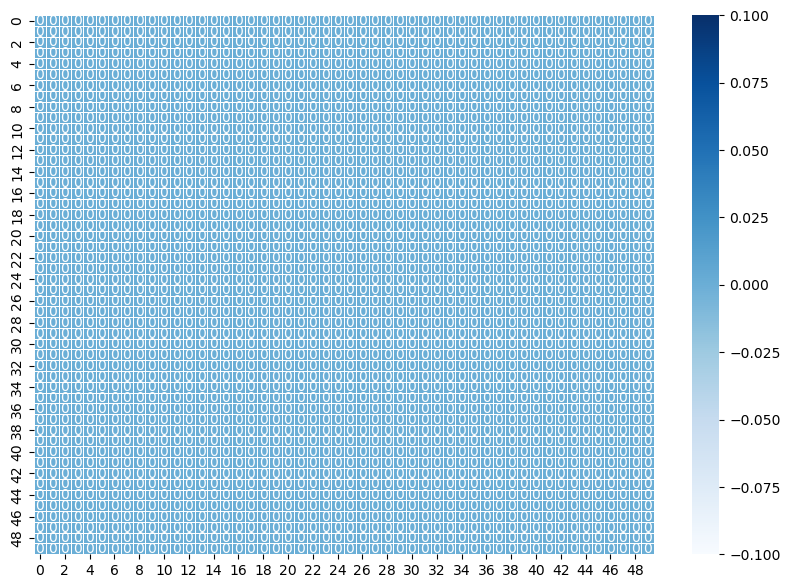

In [18]:
# define figure size
plt.rcParams["figure.figsize"] = (10,7)

# display Omega
sns.heatmap(DataFrame(Omega), cmap='Blues', annot=True, linewidths=.5)

<Axes: >

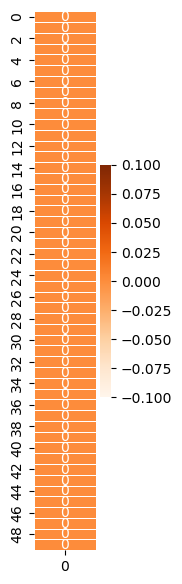

In [19]:
# define  figure size
plt.rcParams["figure.figsize"] = (1,7)

# display xi
sns.heatmap(DataFrame(Xi), cmap='Oranges', annot=True, linewidths=.5)

<Axes: >

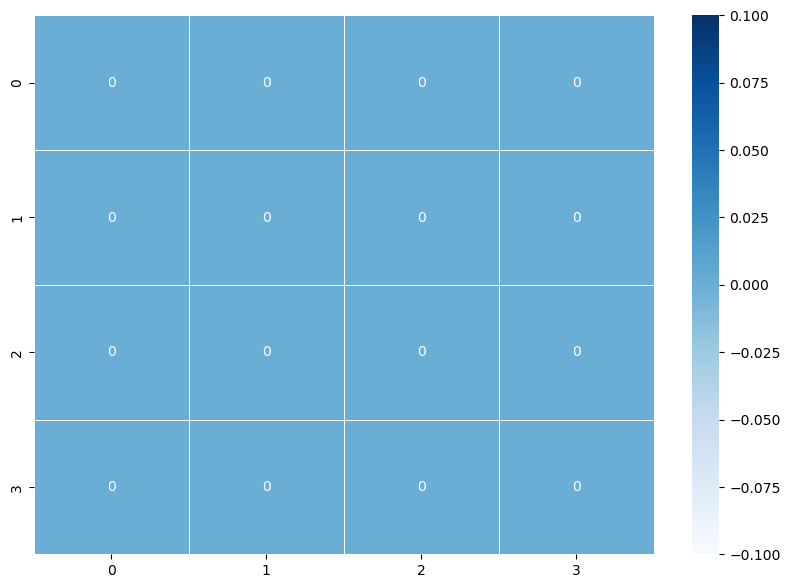

In [20]:
delta_motion = np.zeros((4,4)) ## for one step say from (Px0, Pyo) -> (Px1, Py1)

# define figure size
plt.rcParams["figure.figsize"] = (10,7)

# display omega
sns.heatmap(DataFrame(delta_motion), cmap='Blues', annot=True, linewidths=.5)

<Axes: >

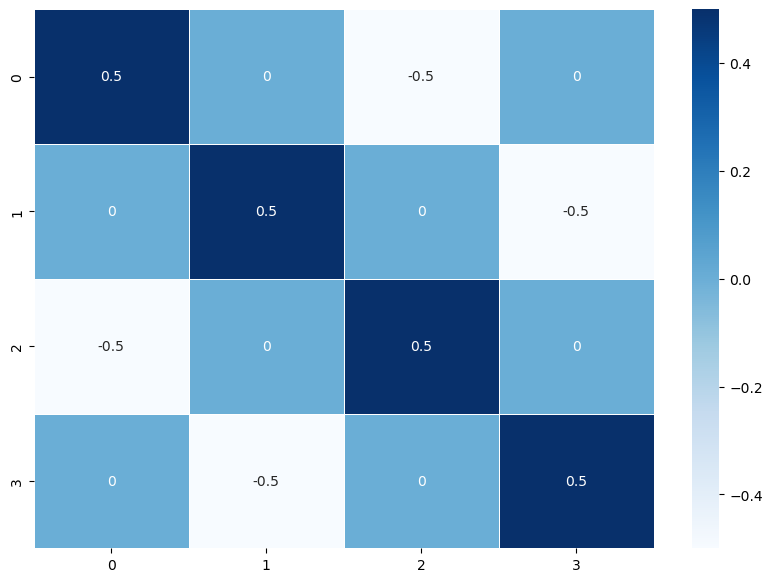

In [21]:
## Fill delta_motion for first movement --- first 4x4 motion from Pxo, Py0 to Px1, Py1

for i in range(4):
    for j in range(4):
        if (i==j): 
            delta_motion[i][j] = 1 / motion_noise
        elif ((i % 2 == 0) and (j % 2 == 0)):
            delta_motion[i][j] = -1 / motion_noise
        elif ((i % 2 != 0) and (j % 2 != 0)):
            delta_motion[i][j] = -1 / motion_noise
        else:
            delta_motion[i][j] = 0
# define figure size
plt.rcParams["figure.figsize"] = (10,7)

# display omega
sns.heatmap(DataFrame(delta_motion), cmap='Blues', annot=True, linewidths=.5)

In [22]:
## dummy motions data [Pxo, Pyo],[Px1, Py1] ..., [Pxn, Pyn]is flatted into [Pxo, Pyo,Px1, Py1 ..., Pxn, Pyn]

motions = [15.947931654811654, -12.069112474969169, 15.947931654811654, -12.069112474969169, 15.947931654811654, -12.069112474969169, -1.8286088644135592, 19.916229302279792, -1.8286088644135592, 19.916229302279792, -1.8286088644135592, 19.916229302279792, -1.8286088644135592, 19.916229302279792, 4.541277139251847, -19.477597437684878, -19.750989841082685, -3.1461723248176594, -19.750989841082685, -3.1461723248176594, -19.750989841082685, -3.1461723248176594, -19.750989841082685, -3.1461723248176594, -19.750989841082685, -3.1461723248176594, -2.9129883419252565, -19.786725320775226, 19.978754460427844, -0.9216128308213509, 19.978754460427844, -0.9216128308213509, 19.978754460427844, -0.9216128308213509, 19.978754460427844, -0.9216128308213509, 8.918886629400294, -17.9012139614023]

print("Total of x's and y's = ", len(motions))

Total of x's and y's =  38


<Axes: >

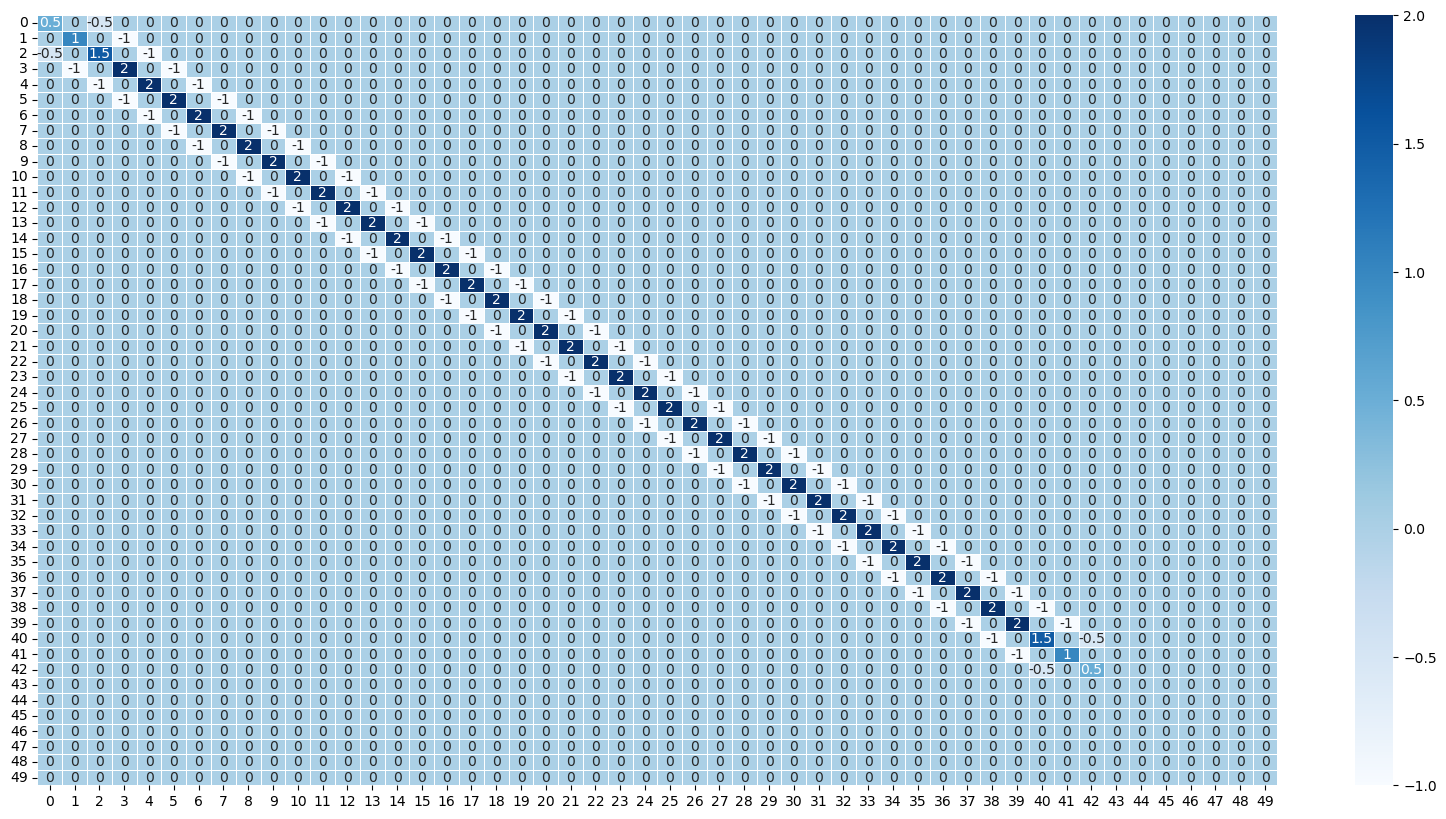

In [23]:
## Now add delta_motion with Omega --- slide delta_motion over whole Omega diaginally --- impact of all N steps
for k in range(2*(N)):
    for i in range(4): 
        for j in range(4): 
                Omega[k+i][k+j] += delta_motion[i][j]

# define figure size
##plt.rcParams["figure.figsize"] = (10,7)
plt.rcParams["figure.figsize"] = (20,10)

# display Omega
sns.heatmap(DataFrame(Omega), cmap='Blues', annot=True, linewidths=.5)

In [24]:
for i in range(len(motions)-1):
    Xi[i] += -motions[i] / motion_noise
    Xi[i+1] += -motions[i+1] / motion_noise
    Xi[i+2] += motions[i] / motion_noise
    Xi[i+3] += motions[i+1] / motion_noise

print(Xi, len(Xi))

[[ -7.97396583]
 [ 12.06911247]
 [ -7.97396583]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [ 17.77654052]
 [-31.98534178]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [ -6.369886  ]
 [ 39.39382674]
 [ 24.29226698]
 [-16.33142511]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [-16.8380015 ]
 [ 16.640553  ]
 [-22.8917428 ]
 [-18.86511249]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [ 11.05986783]
 [  8.02899415]
 [  8.91888663]
 [ -8.95060698]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]
 [  0.        ]] 50


<Axes: >

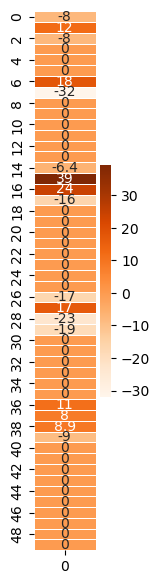

In [25]:
# define  figure size
plt.rcParams["figure.figsize"] = (1,7)

# display xi
sns.heatmap(DataFrame(Xi), cmap='Oranges', annot=True, linewidths=.5)

In [26]:
## dummy measurements data
    
measurements = [[[0, 17.42909058706214, 25.00814747990347], [1, 7.227186457199652, 16.68938009562438], [2, 12.035410843467549, 28.414646916220654], [3, 46.019987964658036, 31.148305110845968], [4, 9.886839509047697, 47.39483910480722]], [[0, 32.16502775256256, 16.793331716262827], [1, 26.29784021169418, 7.9639110819916485], [2, 29.17563188579338, 16.5798343732628], [3, 15.075375213128467, 20.057877857992064], [4, 27.141879032265575, 39.338625269890144]], [[0, 0.5317657353436589, 2.22781846277895], [1, 43.015940937899366, 43.82819758040533], [2, 45.72712737936158, 4.432444369534551], [3, 29.59167836183802, 6.229856432406805], [4, 43.710891812349686, 23.779386720000122]], [[0, 12.999141604575463, 41.86722780083576], [1, 9.257324858814577, 33.924682886422936], [2, 10.788278851466004, 42.193115864187085], [3, 42.906801327782354, 45.5086430087159], [4, 7.474265305288619, 12.161991165507601]], [[0, 13.744050673347722, 12.211804343436846], [1, 7.427229546359968, 4.304182260934879], [2, 7.915321658830003, 11.716157223696005], [3, 43.5159546625215, 16.767958569265133], [4, 8.092000852820389, 35.445795881301464]], [[0, 12.331776192027899, 31.41894785425461], [1, 4.357216859161703, 19.833176482787614], [2, 5.894448433221818, 30.419737809597496], [3, 41.53026913464299, 34.667456581767446], [4, 5.2297314168194475, 2.564323827155989]], [[0, 9.838182259105716, 0.01796986777689824], [1, 1.9408082654398058, 42.51044072808656], [2, 4.7854690070502315, 2.7913755537900187], [3, 39.60222313382505, 6.851867759003487], [4, 4.653095824536576, 23.355037637968806]], [[0, 7.3158545883599935, 20.200383207204112], [1, 0.23680034179750464, 11.981200416027178], [2, 4.275264421771951, 22.22801099009257], [3, 38.25588773702138, 23.32952285992745], [4, 0.6241073921832863, 44.0186679533323]], [[0, 10.371785747241782, 3.8033613570650147], [1, 2.826610346102349, 42.64968535418091], [2, 5.722318590056112, 4.531192754657603], [3, 43.413913213531536, 6.960730248197194], [4, 4.697735592547589, 23.458866884855883]], [[0, 43.49017890511181, 1.3835603606659888], [1, 34.162452645489346, 40.79859679759113], [2, 35.335738565100016, 2.876948542668032], [3, 20.742672557148662, 5.2929960220296985], [4, 35.97484637372271, 21.6630551340925]], [[0, 22.78988698517865, 46.40608639354471], [1, 18.323718634742995, 36.3620660947042], [2, 18.458991288378005, 46.838323493281194], [3, 5.003286210250561, 48.53699601318606], [4, 17.598851665245284, 17.443012163417286]], [[0, 6.275297975546444, 40.52376410721949], [1, 48.54761640592783, 34.422084419278825], [2, 47.772935569281024, 44.967356967753865], [3, 35.005970935370655, 45.8062570378342], [4, 46.210730181195174, 13.847755662882657]], [[0, 37.1614375613634, 38.12488111962965], [1, 27.72960857825644, 30.194666143555928], [2, 32.69801729329055, 39.97300986575236], [3, 15.650136248056391, 42.06542573335677], [4, 27.323233161322165, 8.352503768318345]], [[0, 16.44598421712631, 36.533399439195726], [1, 9.748062352327494, 23.81449229190546], [2, 14.476936680877053, 35.58670381933345], [3, 49.90163189322891, 37.87829448515853], [4, 10.195637703954063, 5.601997239583646]], [[0, 16.127294445000487, 16.960306260179106], [1, 8.53397509841885, 4.766905454279129], [2, 11.05927912196507, 18.070153440368184], [3, 46.19610377085531, 19.758427036161926], [4, 9.94756519719202, 36.905554030109286]], [[0, 37.355638601829604, 13.711696186472528], [1, 30.138570270095073, 5.235982350327895], [2, 31.39018285266654, 15.264937914287795], [3, 19.917624692617096, 19.770620256825218], [4, 30.759070325144265, 37.89365096231865]], [[0, 8.962524502215551, 13.62217584048466], [1, 49.4488318561643, 7.132394831290059], [2, 3.1017219112209045, 15.578958369437496], [3, 38.74761455610462, 18.205095415365143], [4, 0.045171649828319005, 38.660222219135406]], [[0, 27.421529361496347, 14.582321699383295], [1, 19.315212255918645, 5.110604988995367], [2, 24.147312019656326, 16.67437999658109], [3, 7.759621450329991, 18.04126489979485], [4, 18.883730760205463, 36.52241882542823]], [[0, 48.23633502875619, 11.750270747594637], [1, 40.11607096144519, 1.8927513521887294], [2, 43.344192914669634, 14.704789325159386], [3, 28.239493408546732, 15.50531531041284], [4, 41.71504944028039, 33.705631876601785]]] 

print("Total no of measurements = ", len(measurements))

print("for step-0 measurements[0]=", measurements[0])

print("for step-0 landkark-0, measurements[0]=", measurements[0][0])

print("for step-0 landkark-0dx and dy from measurements[0]=", measurements[0][0][1], measurements[0][0][2])

Total no of measurements =  19
for step-0 measurements[0]= [[0, 17.42909058706214, 25.00814747990347], [1, 7.227186457199652, 16.68938009562438], [2, 12.035410843467549, 28.414646916220654], [3, 46.019987964658036, 31.148305110845968], [4, 9.886839509047697, 47.39483910480722]]
for step-0 landkark-0, measurements[0]= [0, 17.42909058706214, 25.00814747990347]
for step-0 landkark-0dx and dy from measurements[0]= 17.42909058706214 25.00814747990347


<Axes: >

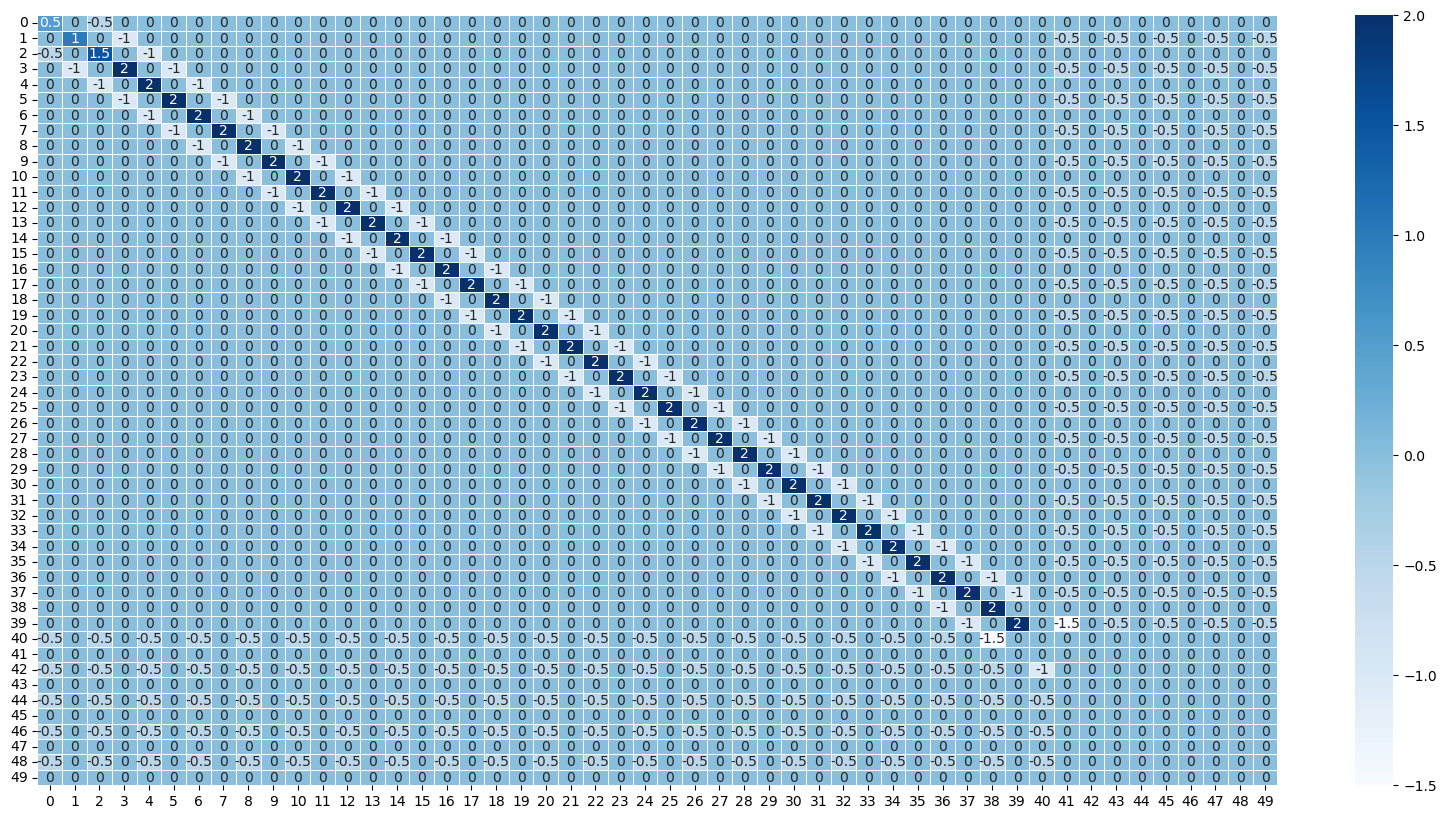

In [27]:
for i in range(2*N, 2*(N+num_landmarks)): ## update x component of due to measurement
    for j in range (0, 2*N+1): 
        if ((i % 2) == 0):
            if (i==j): 
                Omega[i][j] += 1 / measurement_noise
            elif ((i % 2 == 0) and (j % 2 == 0)):
                Omega[i][j] += -1 / measurement_noise
            elif ((i % 2 != 0) and (j % 2 != 0)):
                Omega[i][j] += -1 / measurement_noise
            else:
                Omega[i][j] = 0
        else: 
             Omega[i][j] = 0

for i in range (0, 2*N+1): 
    for j in range(2*N, 2*(N+num_landmarks)): ## update y component of due to measurement
        if((j % 2) != 0):
            if (i==j): 
                Omega[i][j] += 1 / measurement_noise
            elif ((i % 2 == 0) and (j % 2 == 0)):
                Omega[i][j] += -1 / measurement_noise
            elif ((i % 2 != 0) and (j % 2 != 0)):
                Omega[i][j] += -1 / measurement_noise
            else:
                Omega[i][j] = 0
        else: 
            Omega[i][j] = 0

for i in range(2*N+1, 2*(N+num_landmarks)): ## no movement within landmarks
    for j in range (2*N+1, 2*(N+num_landmarks)): 
        Omega[i][j] = 0
        
# define figure size
##plt.rcParams["figure.figsize"] = (10,7)
plt.rcParams["figure.figsize"] = (20,10)

# display Omega
sns.heatmap(DataFrame(Omega), cmap='Blues', annot=True, linewidths=.5)  

In [28]:
## Update Xi with dx and dy components from measurements
for n in range(N-1):
    for i in range(num_landmarks):
        for j in range(len(measurements)):
            #print("n = ", n, " i =", i, " j = ", j)
            Xi[i] += -measurements[n][i][1] / measurement_noise
            Xi[i+1] += -measurements[n][i][2] / measurement_noise
            Xi[i+2] += measurements[n][i][1] / measurement_noise
            Xi[i+3] += measurements[n][i][2] / measurement_noise

<Axes: >

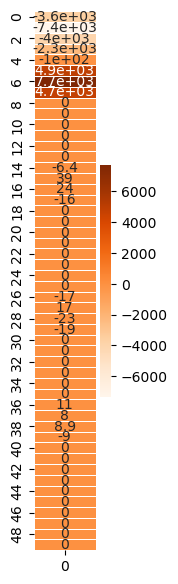

In [29]:
# define  figure size
plt.rcParams["figure.figsize"] = (1,7)

# display xi
sns.heatmap(DataFrame(Xi), cmap='Oranges', annot=True, linewidths=.5)

In [30]:
## Generate mu 

inv_omega = np.linalg.inv(np.matrix(Omega))

LinAlgError: Singular matrix

In [ ]:
# define figure size
##plt.rcParams["figure.figsize"] = (10,7)
plt.rcParams["figure.figsize"] = (20,10)

# display Omega
sns.heatmap(DataFrame(inv_omega), cmap='Blues', annot=True, linewidths=.5)  

In [ ]:
mu = np.matmul(inv_omega, initial_xi)

In [ ]:
# define figure size
plt.rcParams["figure.figsize"] = (10,7)
##plt.rcParams["figure.figsize"] = (20,10)

# display Omega
sns.heatmap(DataFrame(mu), cmap='Blues', annot=True, linewidths=.5)  